In [1]:
import warnings
import time
from dataclasses import dataclass
from typing import Tuple, List
from collections import Counter
import pandas as pd
import numpy as np
from sklearn.preprocessing import (
    MinMaxScaler,
)
from sklearn.linear_model import (
    Lasso,
    LassoCV
)
from sklearn.metrics import (
    silhouette_score,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')

| Item          | Version  |
|-------------------|---------|
| Kernel            | Python 3.12.0 |
| sklearn           | 1.7.1   |
| pandas            | 2.3.2   |
| seaborn           | 0.13.2  |
| matplotlib        | 3.10.6  |

#### 1. Answer the questions from the introduction

##### 1.1 Propose a new method to initialize cluster centroids for K-means. List the advantages and disadvantages of Forgy, Random Partition, and your own initializations.

The new method:

Advantages:
Forgy - <br>
Random Partition - <br>
My - <br>

Disadvantages:
Forgy - <br>
Random Partition - <br>
My - <br>

##### 1.2 Describe how you can use clustering to speed up the KNN model. Hint: what is kd-tree?

Kd-tree - is <br>
Using clustering to speed up the KNN model: <br>

#### 2. Introduction — make all the preprocessing staff from the previous lesson

In [2]:
# csv from materials not from kaggle, test from materials has interest lvl col
path: str = "data/train_test_renthop/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(
    path.format(name="train"), parse_dates=[4], index_col=0,
)
train_df.name = "train_df"
test_df: pd.DataFrame = pd.read_csv(
    path.format(name="test"), parse_dates=[4], index_col=0,
)
test_df.name = "test_df"

In [3]:
for df in train_df, test_df:
    df["features"] = df["features"].apply(
        lambda x: 
            x.replace('"', '').replace('[', '').replace(']', '').replace("'", '').replace(' ', '')
    )

features_list: list = []

for num, row in train_df.iterrows():
    features_list += row['features'].split(',')

features_list = [x for x in features_list if x]
features_list = [x.replace(' ', '') for x in features_list ]
cnt = Counter(features_list).most_common(20)
features_list = [x[0] for x in cnt if x]

for x in features_list:
    train_df[x] = train_df['features'].str.contains(x, regex=False).astype(int)
    test_df[x] = test_df['features'].str.contains(x, regex=False).astype(int)

base_features_list: list = ["bathrooms", "bedrooms", "interest_level"]
features: list = features_list + base_features_list

#### 3. Implement the next methods:

##### 3.1 K-means algorithm.

In [4]:
@dataclass
class KMeans_():
    """
    The KMeans algorithm clusters data by trying to separate samples 
    in n groups of equal variance, minimizing a criterion 
    known as the inertia or within-cluster sum-of-squares

    Prepocess: Standard or MinMax scaler
    Algo complexity (Fit): O(n_train_samples * n_features * n_clusters * n_iter)
    Algo complexity (Predict): O(n_test_samples * n_features * n_clusters)
    """
    n_clusters: int = 8
    n_init: int = 10
    max_iter: int = 300
    tol: float = 1e-4
    random_state: int = 42
    cluster_centers_ = None
    labels_ = None
    inertia_ = None
    n_iter_ = 0
    
    def _init_centroids(self, X, i):
        self.rng = np.random.RandomState(self.random_state + i)
        indices = self.rng.choice(self.n_samples, self.n_clusters, replace=False)
        return X[indices]
    
    def _pairwise_distances_argmin(self, X, centres):
        distances = np.zeros((X.shape[0], centres.shape[0]))
        for i in range(centres.shape[0]):
            distances[:, i] = np.sum((X - centres[i]) ** 2, axis=1)
        
        argmin = np.argmin(distances, axis=1)
        min_dist = distances[np.arange(X.shape[0]), argmin]
        return argmin, min_dist
    
    def _kmeans_single(self, X, init_centers):
        centers = init_centers.copy()
        
        for i in range(self.max_iter):
            labels, distances = self._pairwise_distances_argmin(X, centers)
            new_centers = np.zeros_like(centers)
            for k in range(self.n_clusters):
                if np.any(labels == k):
                    new_centers[k] = X[labels == k].mean(axis=0)
                else:
                    new_centers[k] = X[self.rng.randint(self.n_samples)]
            
            center_shift = np.linalg.norm(new_centers - centers, axis=1)
            max_shift = np.max(center_shift)
            
            centers = new_centers
            
            if max_shift < self.tol:
                break
        
        inertia = np.sum(distances)
        return centers, labels, inertia, i + 1
    
    def fit(self, X, y=None):
        self.n_samples, self.n_features = X.shape
        best_inertia, best_centers, best_labels = float('inf'), None, None
        
        for i in range(self.n_init):
            centers = self._init_centroids(X, i)
            centers, labels, inertia, n_iter = self._kmeans_single(X, centers)

            if inertia < best_inertia:
                best_centers, best_labels, best_inertia = centers, labels, inertia
                self.n_iter_ = n_iter
        
        self.cluster_centers_ = best_centers
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        
        return self
    
    def predict(self, X):
        labels, _ = self._pairwise_distances_argmin(X, self.cluster_centers_)
        return labels
    

def fit_cluster_model(model):
    model.fit(train_df[['latitude', 'longitude']].values)
    train_df['cluster_label'] = model.predict(train_df[['latitude', 'longitude']])
    test_df['cluster_label'] = model.predict(test_df[['latitude', 'longitude']])

    return model


cluster_model = fit_cluster_model(
    model=KMeans_(n_clusters=30, random_state=42, n_init=20)
)

In [5]:
# initial tables:
metrics: dict = {
    'model': [], 
    'Silh_sc_train': [],
    'Silh_sc_test': [],
    "MAE_train": [],
    "MAE_test": [],
    "RMSE_train": [],
    "RMSE_test": [],
    "R2_train": [],
    "R2_test": [],
    "fit/predict_time": []
}

f_imp_res_table: pd.DataFrame = pd.DataFrame()

##### 3.2 Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.

In [6]:
def fit_cluster_model(model, approach: str = "prod"):
    name = model.__class__.__name__.lower()
    start_time = time.time()

    if "means" in name or "gaus" in name:
        model.fit(train_df[['latitude', 'longitude']].values)
        train_df['cluster_label'] = model.predict(train_df[['latitude', 'longitude']])
        test_df['cluster_label'] = model.predict(test_df[['latitude', 'longitude']])
        metrics["fit/predict_time"].append(round(time.time() - start_time, 4))
        return model

    if "scan" in name or "agglomerative" in name:
        # for DBSCAN
        if approach == "kaggle":
            # fit only train_df
            train_df['cluster_label'] = model.fit_predict(train_df[['latitude', 'longitude']].values)
            # instead of predict for test_df like in KMeans
            core_samples_ = train_df[['latitude', 'longitude']].values[model.core_sample_indices_]
            core_labels_ = train_df['cluster_label'].values[model.core_sample_indices_]
            
            nn = NearestNeighbors(n_neighbors=1)
            nn.fit(core_samples_)
            distances, indices = nn.kneighbors(test_df[['latitude', 'longitude']])
            
            test_df['cluster_label'] = np.where(
                distances.flatten() <= model.eps, 
                core_labels_[indices.flatten()], 
                -1
            )
            metrics["fit/predict_time"].append(round(time.time() - start_time, 4))
        
        if approach == "prod":
            # fit all data
            train_df['train'] = 1
            test_df['train'] = 0

            data = pd.concat([train_df, test_df])
            data['cluster_label'] = model.fit_predict(data[['latitude', 'longitude']].values)
            train_df['cluster_label'] = data[data['train']==1]["cluster_label"]
            test_df['cluster_label'] = data[data['train']==0]["cluster_label"]
            metrics["fit/predict_time"].append(round(time.time() - start_time, 4))

        return model


cluster_model = fit_cluster_model(
    model=KMeans_(n_clusters=30, random_state=42, n_init=20)
)

##### 3.3 Compute Silhouette score and Distortion.

##### 3.4 Add the label of the cluster as a feature in the Lasso Regression with MinMaxScaller

##### 3.5 Print the feature importance as the feature weight from the Lasso.

##### The **"Distortion"** - a local minimum of the following cost function.
##### $\sum_{n=1}^N \|\mathbf{x}_n - \boldsymbol{\mu}_{z_n}\|^2$
##### where $\boldsymbol{\mu}_k = \frac{1}{N_k}\sum_{n:z_n=k}\mathbf{x}_n$ is the k-cluster center and 
##### $z_n^* = \arg \min_k \| \mathbf{x}_n - \boldsymbol{\mu}_k \|^2$ is the closest cluster of $\mathbf{x}_n$.

In [7]:
def distortion_score(
        X: pd.DataFrame,
        centers: list,
        labels: list
    ):

    distortion = 0.0
    
    for i in range(len(X)):
        centroid = centers[labels[i]]
        distortion += np.sum((X.iloc[i] - centroid) ** 2)
    
    return distortion

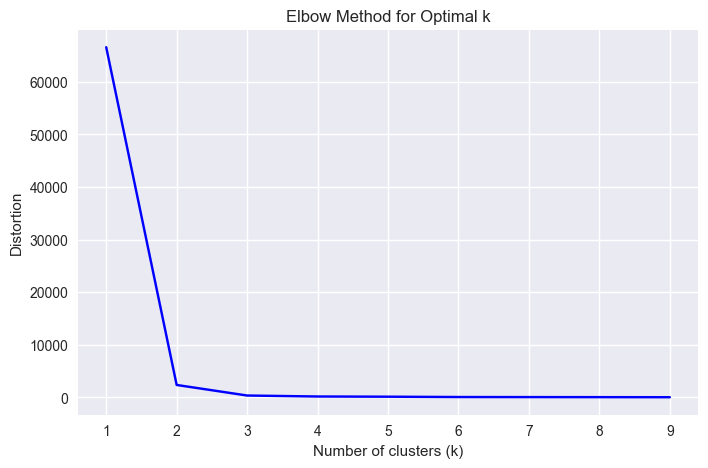

In [8]:
def elbow_method(X: pd.DataFrame):

    K_range, distortions = range(1, 10), []
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
        distortions.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(K_range, distortions, 'bx-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Distortion')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()

elbow_method(X=train_df[['latitude', 'longitude']])

##### The **"Silhouette" coefficient** is computed using the average intra-cluster distance (a) and the average distance to the nearest cluster (b) for each instance i. <br> We define the silhouette coefficient of an instance i as $` \text{sc}(i) = (b_i - a_i) / \max(a_i, b_i) `$. <br>*Source: [Hidden Markov models for malware classification](https://www.researchgate.net/publication/272017073_Hidden_Markov_models_for_malware_classification)*

![Hidden Markov models for malware classification](../misc/images/hidden_markov_models_for_malware_classification.png)
##### What does it mean? This coefficient varies between -1 and +1. <br>If it is +1, the instance is close to all members of its cluster and far from other clusters; <br>a value of 0 means it is close to a cluster boundary; <br>and a value of -1 means it may be in the wrong cluster. <br>(The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters - sklearn*) <br>Then it is possible to calculate the **silhouette score** of a clustering K as the average silhouette coefficient over all samples.

In [9]:
def silhouette_coef(X: np.array, labels: list):
    n_samples, unique_labels = len(X), np.unique(labels)
    n_clusters = len(unique_labels)
    
    if n_clusters <= 1 or n_clusters == n_samples:
        return 0.0
    
    clusters = {label: np.where(labels == label)[0] for label in unique_labels}
    silhouette_values = np.zeros(n_samples)
    
    for i in range(n_samples):
        current_label = labels[i]
        current_cluster_indices = clusters[current_label]
        
        mask = current_cluster_indices != i
        same_cluster_indices = current_cluster_indices[mask]
        if len(same_cluster_indices) > 0:
            diff = X[same_cluster_indices] - X[i]
            # np.linalg.norm - euclidian dist
            distances = np.linalg.norm(diff, axis=1)
            a_i = np.mean(distances)
        else:
            a_i = 0
        
        other_cluster_means = []
        for label, indices in clusters.items():
            if label != current_label:
                diff = X[indices] - X[i]
                distances = np.linalg.norm(diff, axis=1)
                other_cluster_means.append(np.mean(distances))
        
        if len(other_cluster_means) > 0:
            b_i = np.min(other_cluster_means)
        else:
            b_i = 0
        
        if max(a_i, b_i) > 0:
            silhouette_values[i] = (b_i - a_i) / max(a_i, b_i)
    
    return np.mean(silhouette_values)

In [10]:
def calc_metrics(name: str, eval_model, results: dict):
    results['model'].append(name)
    # silhouette_score
    results['Silh_sc_train'].append(
        round(
            silhouette_score(train_df[['latitude', 'longitude']], train_df['cluster_label']), 4
        )
    )
    results['Silh_sc_test'].append(
        round(
            silhouette_score(test_df[['latitude', 'longitude']], test_df['cluster_label']), 4
        )
    )

    # eval model
    X_train: pd.DataFrame = train_df[features + ['cluster_label']]
    y_train: pd.DataFrame = train_df["price"]

    X_test: pd.DataFrame = test_df[features + ['cluster_label']]
    y_test: pd.DataFrame = test_df["price"]

    sc = MinMaxScaler()
    X_train_norm = pd.DataFrame(sc.fit_transform(X=X_train))
    X_test_norm = pd.DataFrame(sc.transform(X=X_test))

    model = eval_model
    model.fit(X_train_norm, y_train)

    y_pred_train = model.predict(X_train_norm)
    y_pred_test = model.predict(X_test_norm)

    for name, metric in (
        ("MAE", mean_absolute_error), 
        ("RMSE", root_mean_squared_error), 
        ("R2", r2_score)
    ):
        results[f"{name}_train"].append(
            round(metric(y_true=y_train, y_pred=y_pred_train), 4)
        )
        results[f"{name}_test"].append(
            round(metric(y_true=y_test, y_pred=y_pred_test), 4)
        )

    return model


model = calc_metrics(
    name="KMeans_lat_lon", 
    eval_model=Lasso(random_state=42), 
    results=metrics, 
)

In [11]:
# check implementation
print(metrics["Silh_sc_train"])
print(metrics["Silh_sc_test"])
# print(silhouette_coef(train_df[['latitude', 'longitude']].values, train_df['cluster_label'].values))
# print(silhouette_coef(test_df[['latitude', 'longitude']].values, test_df['cluster_label'].values))

print(cluster_model.inertia_)
print(
    distortion_score(
        X=train_df[['latitude', 'longitude']], 
        centers=cluster_model.cluster_centers_, 
        labels=cluster_model.labels_)
)

[0.4218]
[0.4203]
12.7805616845333
12.780558554697487


In [12]:
pd.DataFrame(metrics)

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_lat_lon,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,16.1596


In [13]:
def calc_feature_importance(res_table: pd.DataFrame, model_name: str, model):
    feature_importance: pd.DataFrame = pd.DataFrame()
    feature_importance[model_name] = features + ['cluster_label']
    feature_importance['ftr_imp'] = model.coef_
    feature_importance = feature_importance.sort_values(by='ftr_imp', key=abs)
    
    return pd.concat([feature_importance.reset_index(drop=True), res_table], axis=1)


calc_feature_importance(
    res_table=f_imp_res_table, 
    model_name="KMeans_lat_lon", 
    model=model
)

,KMeans_lat_lon,ftr_imp
0,CatsAllowed,-0.000000
1,Balcony,0.000000
2,NewConstruction,-45.851264
3,OutdoorSpace,-47.395610
4,Pre-War,-53.334064
5,DogsAllowed,68.410690
6,SwimmingPool,69.501912
7,NoFee,-87.407392
8,RoofDeck,-101.643396
9,HardwoodFloors,-106.619386


##### 3.6 Draw result with scatterplot, try to analyze it.

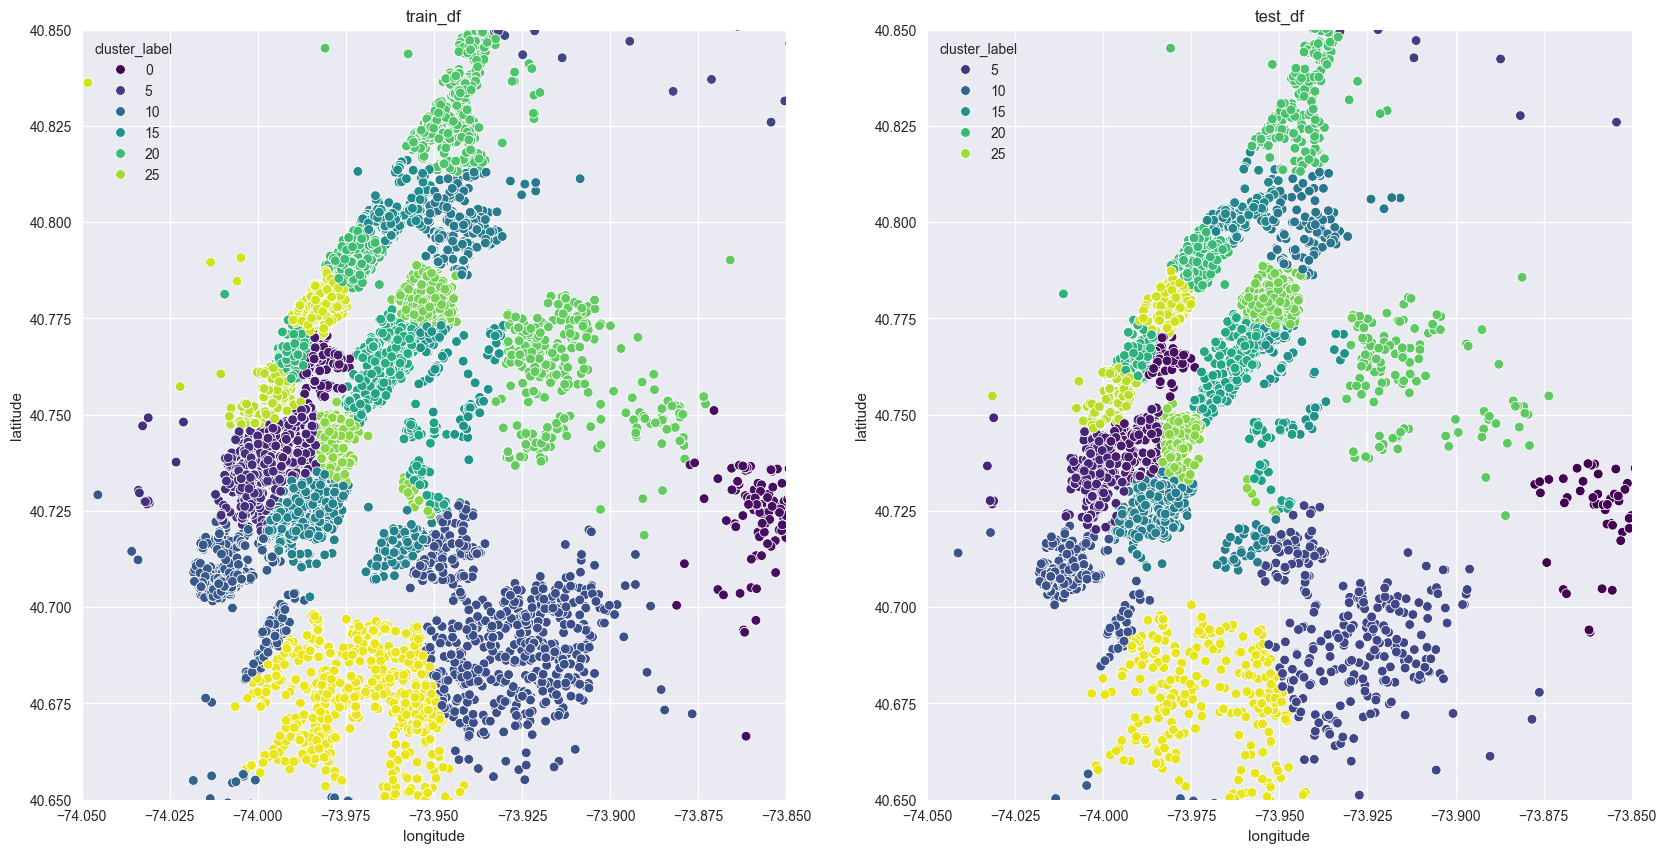

In [14]:
def draw_res():
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
    for num, df in enumerate((train_df, test_df)):
        sns.scatterplot(
            x=df['longitude'], 
            y=df['latitude'], 
            hue=df['cluster_label'], 
            ax=ax[num],
            palette='viridis'
        )
        ax[num].set(xlim=(-74.05,-73.85))
        ax[num].set(ylim=(40.65,40.85))
        ax[num].set(title=df.name)


draw_res()

##### 3.7 Import K-means from sklearn and compare results.

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_lat_lon,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,16.1596
1,KMeans_lat_lon_sk,0.4698,0.4673,679.3550,667.6030,992.1395,959.6436,0.6158,0.6116,0.0743


,KMeans_lat_lon_sk,ftr_imp
0,CatsAllowed,-0.000000
1,Balcony,-0.000000
2,OutdoorSpace,-29.355848
3,Pre-War,-38.085806
4,NewConstruction,-44.052604
5,SwimmingPool,52.749926
6,DogsAllowed,62.127898
7,RoofDeck,-90.085070
8,NoFee,-97.972984
9,HardwoodFloors,-125.660616


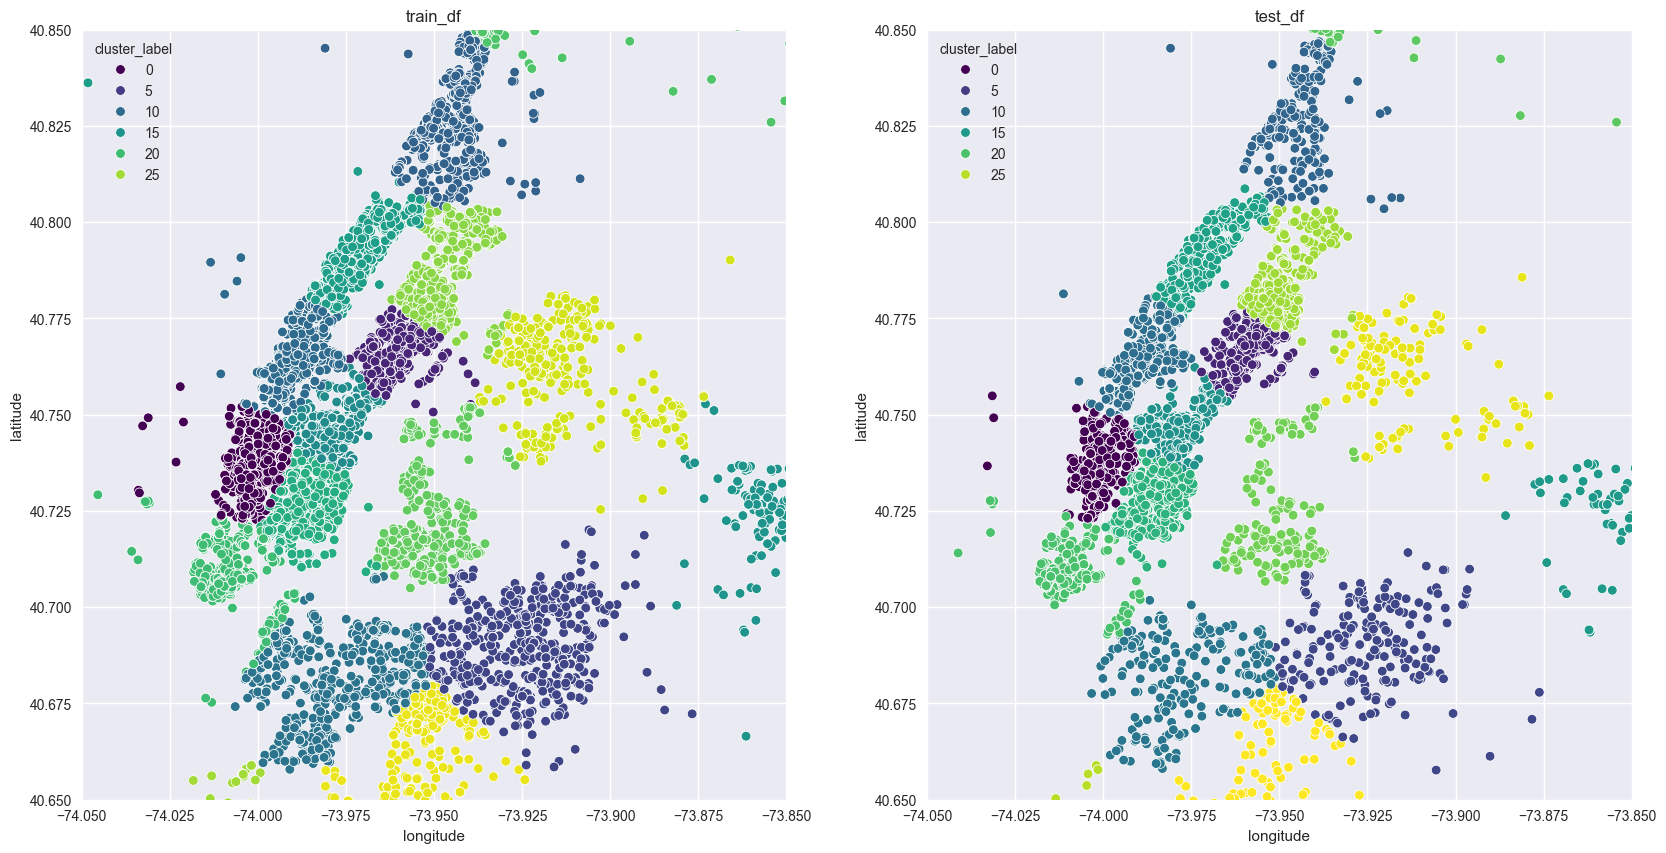

In [15]:
def calc_all(
        model, 
        model_name: str, 
        eval_model, 
        f_imp_res_table: pd.DataFrame, 
        approach: str = "prod"
    ):

    fit_cluster_model(model=model, approach=approach)
    model = calc_metrics(
        name=model_name, 
        eval_model=eval_model, 
        results=metrics, 
    )
    display(pd.DataFrame(metrics))
    f_imp_res_table = calc_feature_importance(
        res_table=f_imp_res_table, 
        model_name=model_name, 
        model=model
    )
    display(f_imp_res_table)
    draw_res()

    return f_imp_res_table


f_imp_res_table = calc_all(
    model=KMeans(n_clusters=30, random_state=42), 
    model_name="KMeans_lat_lon_sk", 
    eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table,
)

#### 4. Implement the next method:

##### 4.1 DBScan algorithm.

In [16]:
@dataclass
class DBSCAN_():
    """
    DBSCAN - Density-Based Spatial Clustering of Applications with Noise. 
    Finds core samples of high density and expands clusters from them. 
    This algorithm is particularly good for data which contains clusters 
    of similar density and can find clusters of arbitrary shape.

    Prepocess: Standard or MinMax scaler
    Algo complexity (Fit): O(n_samples * log(n_samples)) with spatial indexing,
                           O(n_samples^2) without indexing
    Algo complexity (Predict): O(n_samples * n_features)
    """


##### 4.2 Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_lat_lon,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,16.1596
1,KMeans_lat_lon_sk,0.4698,0.4673,679.3550,667.6030,992.1395,959.6436,0.6158,0.6116,0.0743
2,DBSCAN_lat_lon_sk_prod,-0.1712,-0.1730,680.7352,668.2748,993.8240,962.0382,0.6144,0.6097,0.4760


,DBSCAN_lat_lon_sk_prod,ftr_imp,KMeans_lat_lon_sk,ftr_imp
0,CatsAllowed,-0.000000,CatsAllowed,-0.000000
1,Balcony,-0.000000,Balcony,-0.000000
2,NewConstruction,-2.472187,OutdoorSpace,-29.355848
3,SwimmingPool,32.228306,Pre-War,-38.085806
4,OutdoorSpace,-43.040942,NewConstruction,-44.052604
5,Pre-War,-57.444664,SwimmingPool,52.749926
6,DogsAllowed,76.456335,DogsAllowed,62.127898
7,NoFee,-86.343272,RoofDeck,-90.085070
8,RoofDeck,-105.515742,NoFee,-97.972984
9,Dishwasher,120.473126,HardwoodFloors,-125.660616


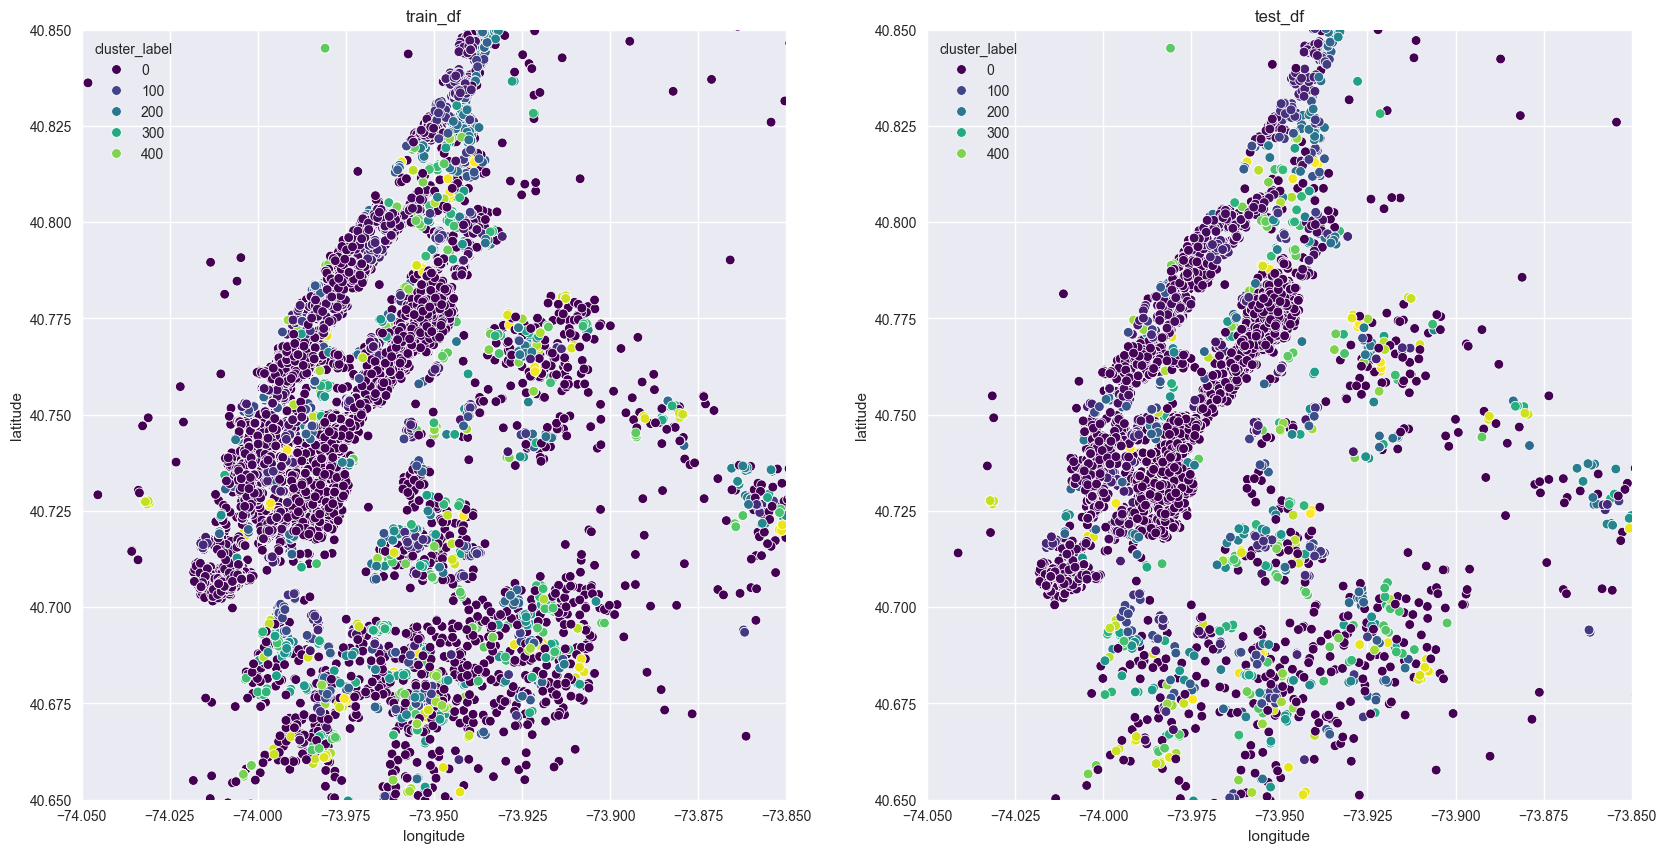

In [17]:
f_imp_res_table = calc_all(
    model=DBSCAN(min_samples=5, eps=0.001), 
    model_name="DBSCAN_lat_lon_sk_prod", 
    eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table,
)

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_lat_lon,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,16.1596
1,KMeans_lat_lon_sk,0.4698,0.4673,679.3550,667.6030,992.1395,959.6436,0.6158,0.6116,0.0743
2,DBSCAN_lat_lon_sk_prod,-0.1712,-0.1730,680.7352,668.2748,993.8240,962.0382,0.6144,0.6097,0.4760
3,DBSCAN_lat_lon_sk_kaggle,-0.0746,-0.0916,684.7196,674.9827,998.3262,967.5796,0.6109,0.6052,0.3556


,DBSCAN_lat_lon_sk_kaggle,ftr_imp,DBSCAN_lat_lon_sk_prod,ftr_imp,KMeans_lat_lon_sk,ftr_imp
0,CatsAllowed,-0.000000,CatsAllowed,-0.000000,CatsAllowed,-0.000000
1,Balcony,0.000000,Balcony,-0.000000,Balcony,-0.000000
2,NewConstruction,-16.499624,NewConstruction,-2.472187,OutdoorSpace,-29.355848
3,SwimmingPool,27.962337,SwimmingPool,32.228306,Pre-War,-38.085806
4,OutdoorSpace,-43.952850,OutdoorSpace,-43.040942,NewConstruction,-44.052604
5,Pre-War,-48.979875,Pre-War,-57.444664,SwimmingPool,52.749926
6,DogsAllowed,75.400159,DogsAllowed,76.456335,DogsAllowed,62.127898
7,NoFee,-90.497505,NoFee,-86.343272,RoofDeck,-90.085070
8,RoofDeck,-108.732310,RoofDeck,-105.515742,NoFee,-97.972984
9,HardwoodFloors,-125.145172,Dishwasher,120.473126,HardwoodFloors,-125.660616


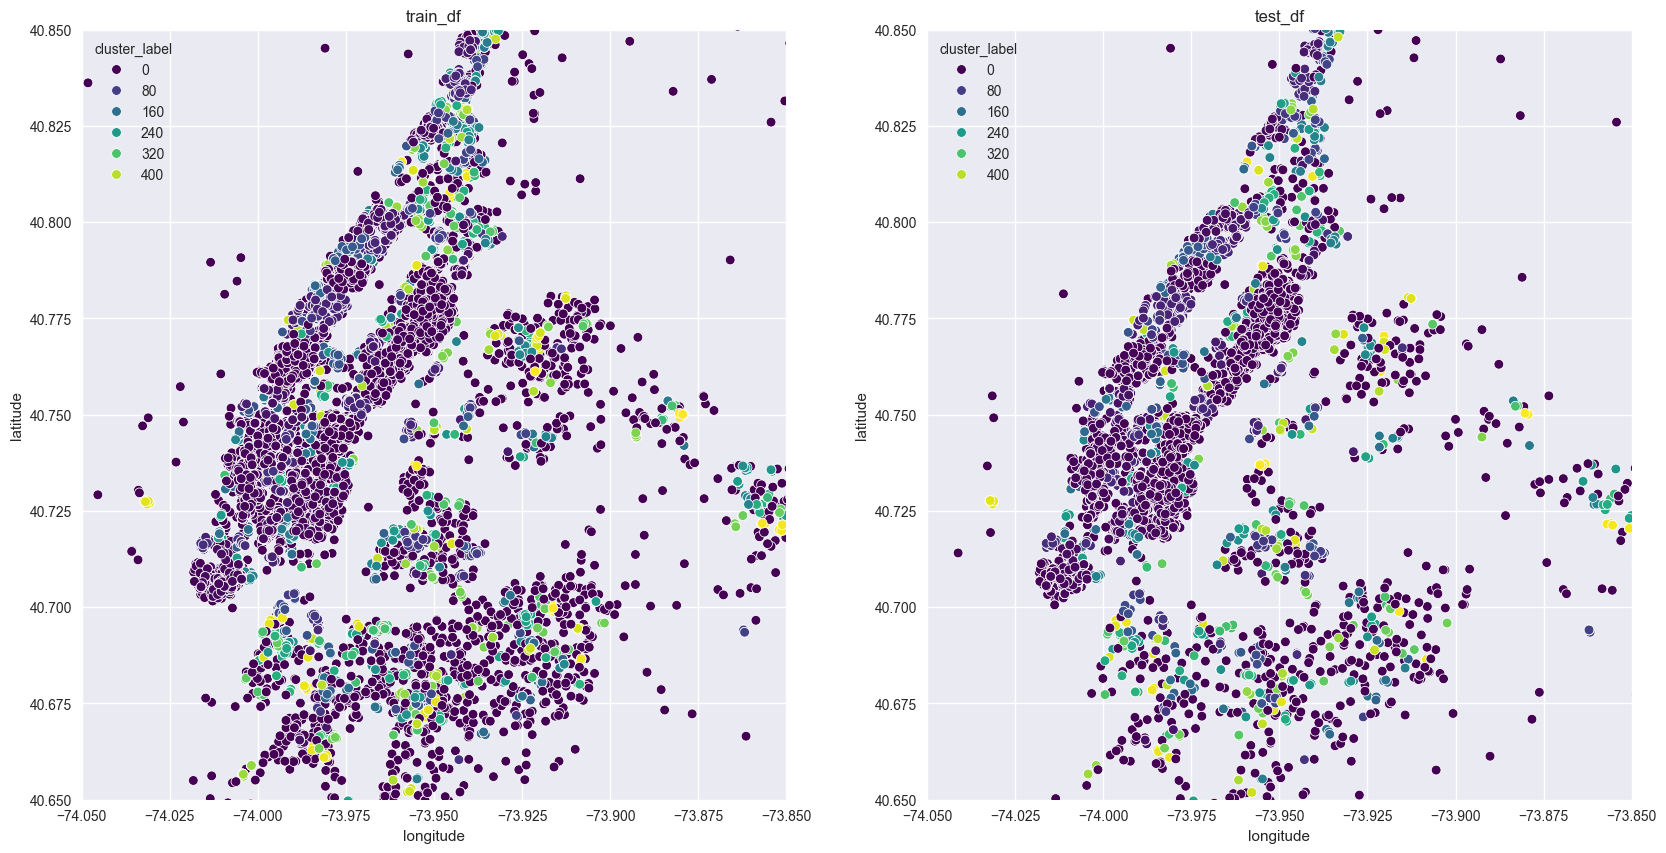

In [18]:
f_imp_res_table = calc_all(
    model=DBSCAN(min_samples=5, eps=0.001), 
    model_name="DBSCAN_lat_lon_sk_kaggle", 
    eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table,
    approach="kaggle"
)

#### 5. Implement the next method:

##### 5.1 AgglomerativeClustering algorithm.

In [19]:
@dataclass
class AgglomerativeClustering_():
    pass

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_lat_lon,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,16.1596
1,KMeans_lat_lon_sk,0.4698,0.4673,679.3550,667.6030,992.1395,959.6436,0.6158,0.6116,0.0743
2,DBSCAN_lat_lon_sk_prod,-0.1712,-0.1730,680.7352,668.2748,993.8240,962.0382,0.6144,0.6097,0.4760
3,DBSCAN_lat_lon_sk_kaggle,-0.0746,-0.0916,684.7196,674.9827,998.3262,967.5796,0.6109,0.6052,0.3556
4,AgglomerativeClustering_sk,0.4795,0.4774,675.1584,661.7636,990.8257,955.0347,0.6168,0.6154,554.3462


,AgglomerativeClustering_sk,ftr_imp,DBSCAN_lat_lon_sk_kaggle,ftr_imp,DBSCAN_lat_lon_sk_prod,ftr_imp,KMeans_lat_lon_sk,ftr_imp
0,CatsAllowed,0.000000,CatsAllowed,-0.000000,CatsAllowed,-0.000000,CatsAllowed,-0.000000
1,Balcony,9.355268,Balcony,0.000000,Balcony,-0.000000,Balcony,-0.000000
2,Pre-War,-52.581110,NewConstruction,-16.499624,NewConstruction,-2.472187,OutdoorSpace,-29.355848
3,DogsAllowed,55.423013,SwimmingPool,27.962337,SwimmingPool,32.228306,Pre-War,-38.085806
4,NewConstruction,-63.021892,OutdoorSpace,-43.952850,OutdoorSpace,-43.040942,NewConstruction,-44.052604
5,OutdoorSpace,-67.342159,Pre-War,-48.979875,Pre-War,-57.444664,SwimmingPool,52.749926
6,NoFee,-77.681462,DogsAllowed,75.400159,DogsAllowed,76.456335,DogsAllowed,62.127898
7,HardwoodFloors,-94.509222,NoFee,-90.497505,NoFee,-86.343272,RoofDeck,-90.085070
8,SwimmingPool,94.964770,RoofDeck,-108.732310,RoofDeck,-105.515742,NoFee,-97.972984
9,RoofDeck,-113.890233,HardwoodFloors,-125.145172,Dishwasher,120.473126,HardwoodFloors,-125.660616


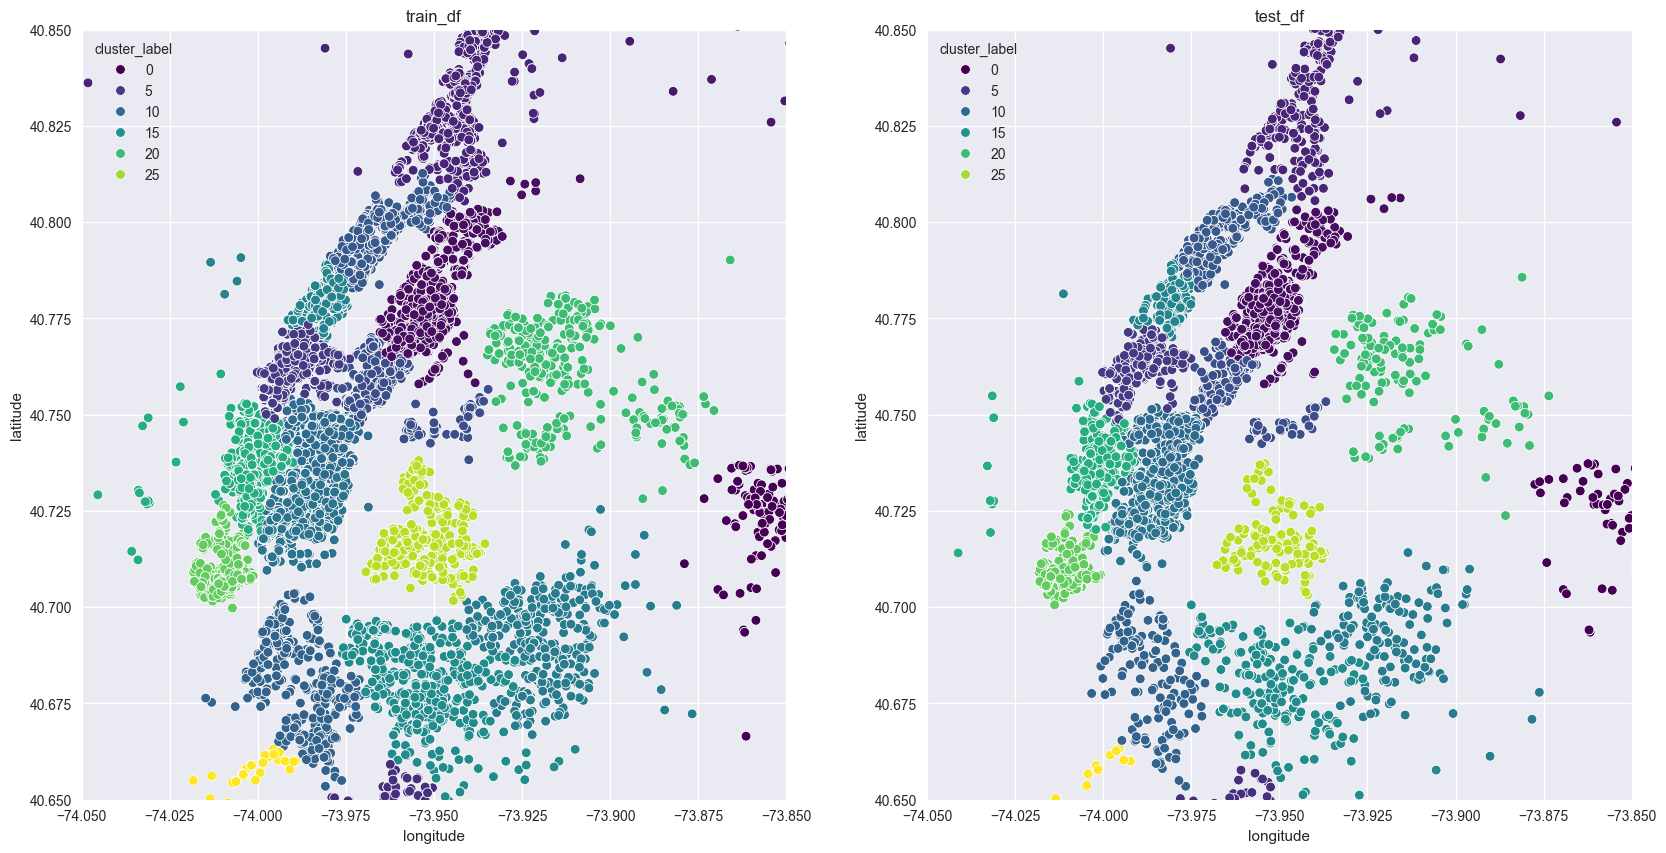

In [20]:
# algorithm is not mandatory for you, you can import it from sklearn.
f_imp_res_table = calc_all(
    model=AgglomerativeClustering(n_clusters=30), 
    model_name="AgglomerativeClustering_sk", 
    eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table
)

#### 6. Implement the next method:

##### 6.1 Gaussian Mixture algorithm.

In [21]:
@dataclass
class GaussianMixture_():
    pass

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_lat_lon,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,16.1596
1,KMeans_lat_lon_sk,0.4698,0.4673,679.3550,667.6030,992.1395,959.6436,0.6158,0.6116,0.0743
2,DBSCAN_lat_lon_sk_prod,-0.1712,-0.1730,680.7352,668.2748,993.8240,962.0382,0.6144,0.6097,0.4760
3,DBSCAN_lat_lon_sk_kaggle,-0.0746,-0.0916,684.7196,674.9827,998.3262,967.5796,0.6109,0.6052,0.3556
4,AgglomerativeClustering_sk,0.4795,0.4774,675.1584,661.7636,990.8257,955.0347,0.6168,0.6154,554.3462
5,GaussianMixture_sk,0.4256,0.4230,690.5436,679.3908,1005.0694,972.1460,0.6057,0.6015,2.6328


,GaussianMixture_sk,ftr_imp,AgglomerativeClustering_sk,ftr_imp,DBSCAN_lat_lon_sk_kaggle,ftr_imp,DBSCAN_lat_lon_sk_prod,ftr_imp,KMeans_lat_lon_sk,ftr_imp
0,Balcony,-0.000000,CatsAllowed,0.000000,CatsAllowed,-0.000000,CatsAllowed,-0.000000,CatsAllowed,-0.000000
1,CatsAllowed,-2.439618,Balcony,9.355268,Balcony,0.000000,Balcony,-0.000000,Balcony,-0.000000
2,SwimmingPool,28.485656,Pre-War,-52.581110,NewConstruction,-16.499624,NewConstruction,-2.472187,OutdoorSpace,-29.355848
3,cluster_label,35.730657,DogsAllowed,55.423013,SwimmingPool,27.962337,SwimmingPool,32.228306,Pre-War,-38.085806
4,OutdoorSpace,-41.865918,NewConstruction,-63.021892,OutdoorSpace,-43.952850,OutdoorSpace,-43.040942,NewConstruction,-44.052604
5,NewConstruction,-49.293645,OutdoorSpace,-67.342159,Pre-War,-48.979875,Pre-War,-57.444664,SwimmingPool,52.749926
6,Pre-War,-50.089521,NoFee,-77.681462,DogsAllowed,75.400159,DogsAllowed,76.456335,DogsAllowed,62.127898
7,DogsAllowed,71.049411,HardwoodFloors,-94.509222,NoFee,-90.497505,NoFee,-86.343272,RoofDeck,-90.085070
8,NoFee,-93.411337,SwimmingPool,94.964770,RoofDeck,-108.732310,RoofDeck,-105.515742,NoFee,-97.972984
9,RoofDeck,-101.802185,RoofDeck,-113.890233,HardwoodFloors,-125.145172,Dishwasher,120.473126,HardwoodFloors,-125.660616


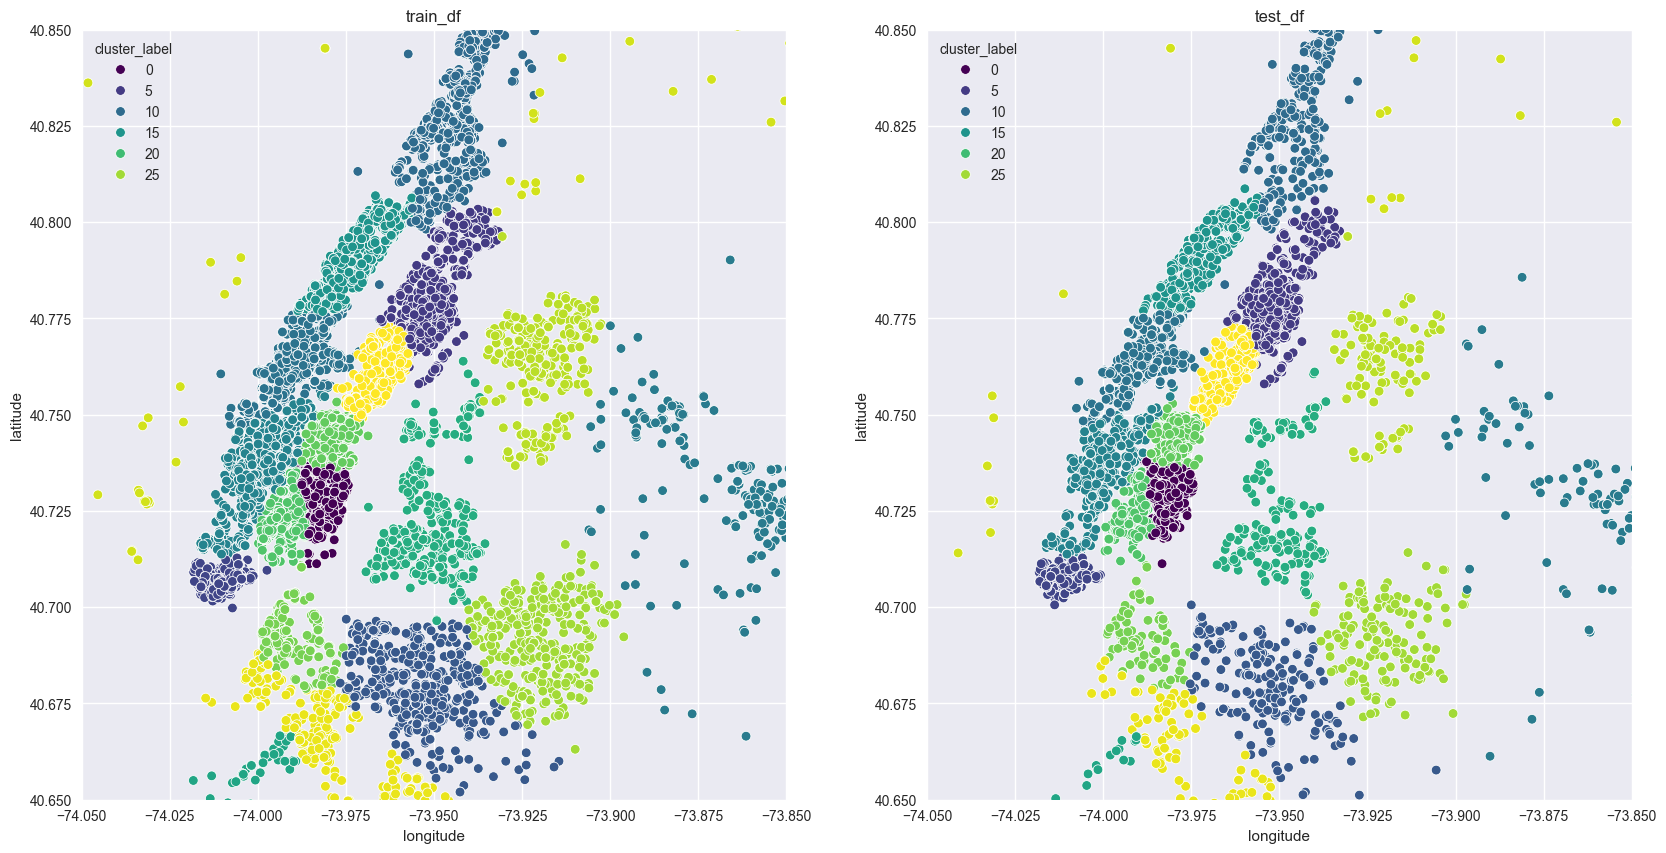

In [22]:
f_imp_res_table = calc_all(
    model=GaussianMixture(n_components=30), 
    model_name="GaussianMixture_sk", 
    eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table
)

#### 7. Try all these algorithms with different sets of features that might be more efficient in clustering.<br> In the checklist will cluster for 3 features — bedrooms, bathrooms and interest_level.

#### 8. Compare the results with the complexity, speed and accuracy of these methods.

#### Bonus:

##### B1. For additional task, you can try different models instead of Lasso.

##### B2. You could apply optimization methods to hyperparameters of algorithms, e.g. to find the optimal number of clusters.

##### B3. You could apply optimization methods to hyperparameters of algorithms, e.g. to find the optimal number of clusters.

#### * Sources
- Part 3.3 Silhouette coefficient [Hidden Markov models for malware classification](https://www.researchgate.net/publication/272017073_Hidden_Markov_models_for_malware_classification)